# 02 — Exploratory Data Analysis

**Project:** End-to-End Heart Disease Prediction System
**Stage:** 2 / 5 — Exploratory Data Analysis

## Objective
Before engineering any features, we need to understand the data we are working
with: how balanced is the target class, which numeric features correlate with
heart disease, and how do key clinical markers (chest pain type, ST slope,
exercise-induced angina) split across the two outcome classes?

The insights from this notebook directly motivate the domain-knowledge features
built in `03_Feature_Engineering.ipynb`.

## Input
- `data/interim/train_imputed.csv` (output of Notebook 01)

## Output
- Exploratory figures saved to `reports/figures/`

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

INTERIM_DIR = "../data/interim"
FIGURES_DIR = "../reports/figures"

train = pd.read_csv(f"{INTERIM_DIR}/train_imputed.csv")
train.head()

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,RestingBP_was_zero,Cholesterol_was_zero
0,1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0.0,0,0
1,2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1.0,0,0
2,3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0.0,0,0
3,4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1.0,0,0
4,5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0.0,0,0


## 2. Target Distribution

Target distribution (HeartDisease):
HeartDisease
1.0    0.546
0.0    0.454
Name: proportion, dtype: float64


C:\Users\Ravi tirta\AppData\Local\Temp\ipykernel_12740\32420703.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='HeartDisease', palette=['#A9CCE3', '#154360'])


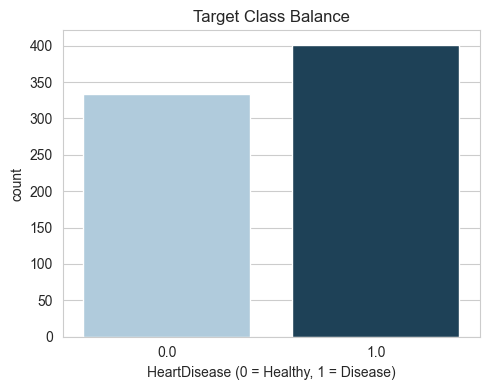

In [2]:
print("Target distribution (HeartDisease):")
print(train['HeartDisease'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(data=train, x='HeartDisease', palette=['#A9CCE3', '#154360'])
plt.title('Target Class Balance')
plt.xlabel('HeartDisease (0 = Healthy, 1 = Disease)')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

The classes are reasonably balanced, which means accuracy alone would not be
dangerously misleading — but for a **clinical screening problem**, the cost of
a False Negative (telling a sick patient they are healthy) is far higher than
a False Positive. This motivates the dual-threshold strategy used later in
Notebook 04.

## 3. Correlation Matrix — Numeric Features

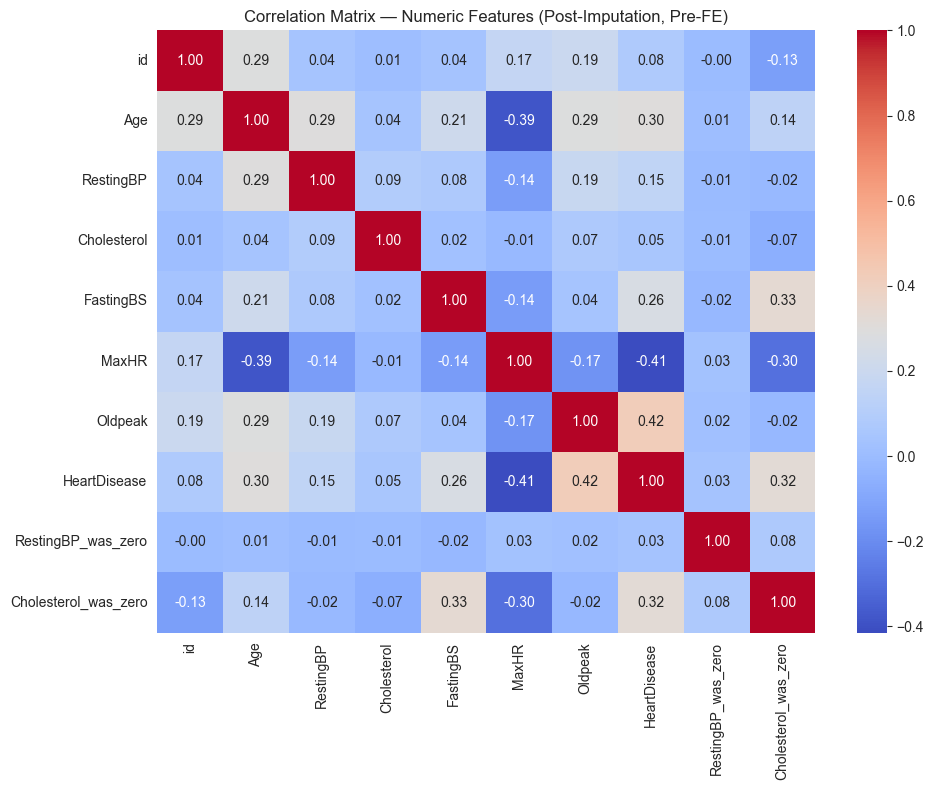

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix — Numeric Features (Post-Imputation, Pre-FE)')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/correlation_matrix_pre_fe.png", dpi=150, bbox_inches='tight')
plt.show()

**Key observation:** `Oldpeak` (ST depression induced by exercise) and the
categorical `ST_Slope` consistently show among the strongest associations with
`HeartDisease`. This is consistent with cardiology literature — both are
classic exercise-stress-test markers of myocardial ischemia, and they directly
inform the `Ischemia_Risk` domain feature built in Notebook 03.

## 4. Numeric Feature Distributions by Target

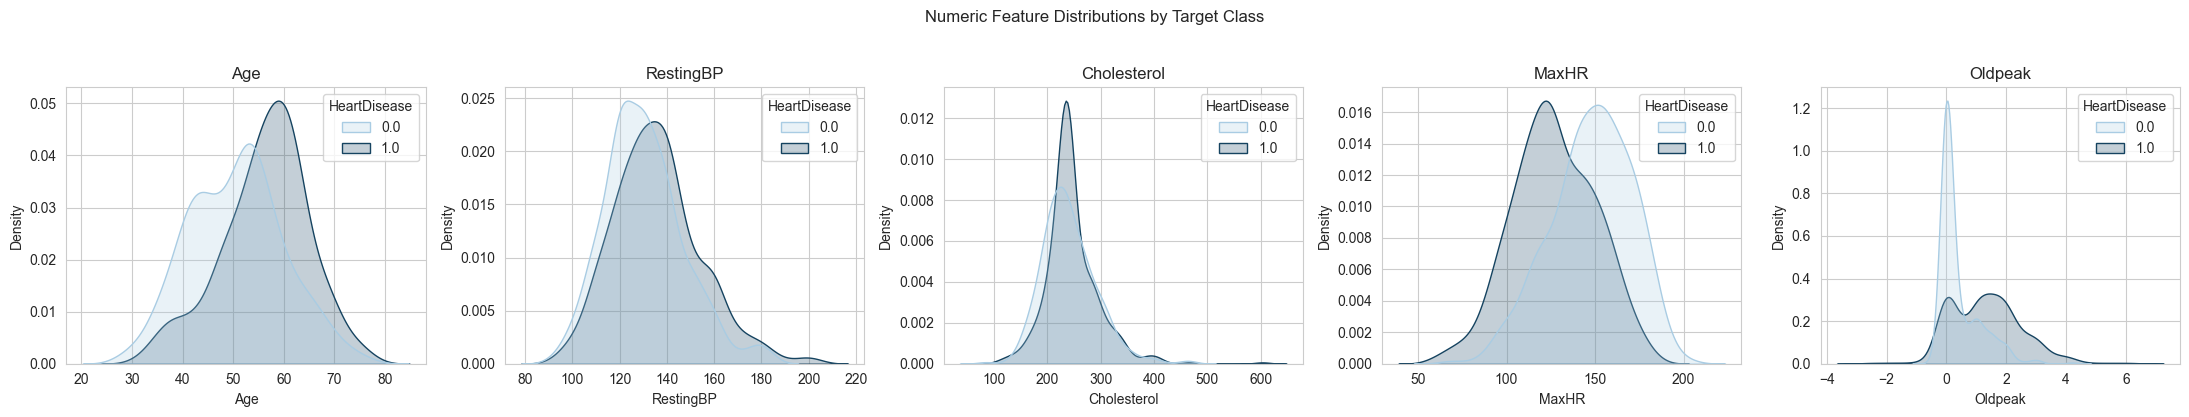

In [4]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(22, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=train, x=col, hue='HeartDisease', fill=True, ax=ax,
                palette=['#A9CCE3', '#154360'], common_norm=False)
    ax.set_title(col)
plt.suptitle('Numeric Feature Distributions by Target Class', y=1.03)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/numeric_distributions_by_target.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Markers vs Target

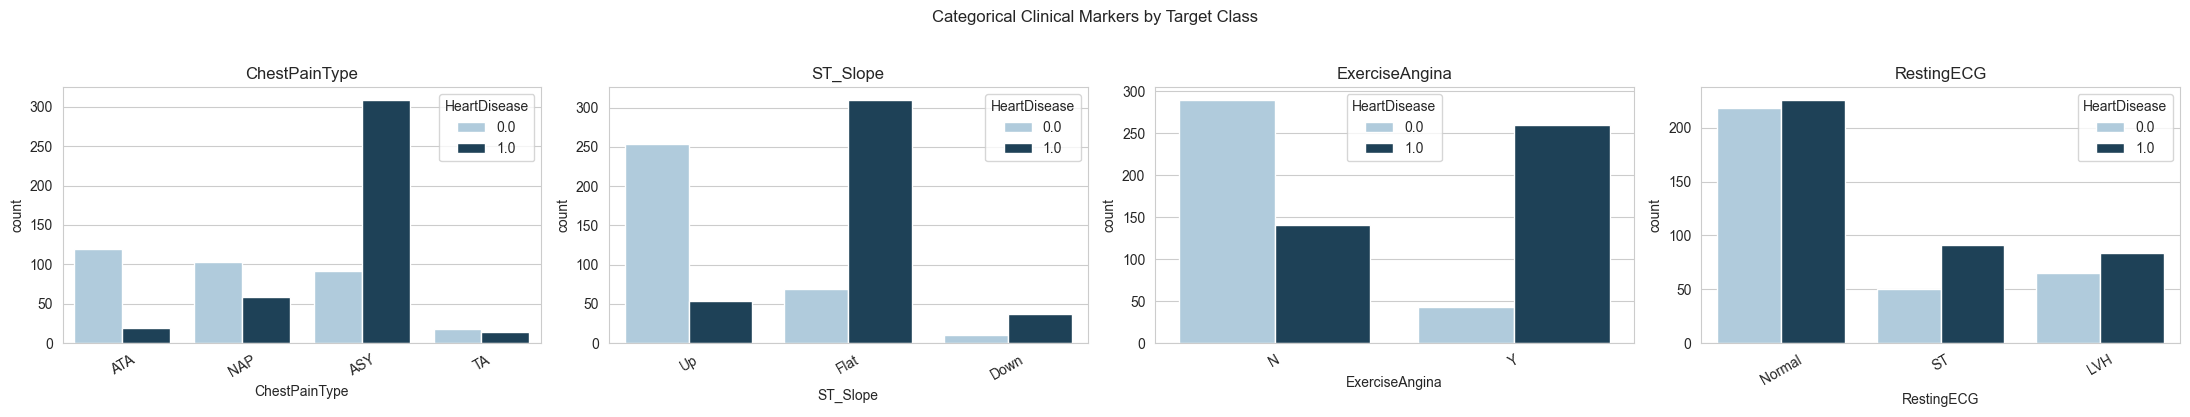

In [5]:
categorical_cols = ['ChestPainType', 'ST_Slope', 'ExerciseAngina', 'RestingECG']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(22, 4))
for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=train, x=col, hue='HeartDisease', ax=ax,
                  palette=['#A9CCE3', '#154360'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Categorical Clinical Markers by Target Class', y=1.03)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/categorical_markers_by_target.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Key EDA Takeaways → Feature Engineering Hypotheses

| Observation | Engineering Hypothesis (built in Notebook 03) |
|---|---|
| Asymptomatic chest pain (`ASY`) is disproportionately associated with disease | Counter-intuitive marker worth encoding explicitly via OHE |
| High `Oldpeak` + `Flat`/`Down` `ST_Slope` co-occur with disease | Combine into a single `Ischemia_Risk` interaction flag |
| `RestingBP`, `Cholesterol`, `FastingBS` jointly elevated in disease cases | Combine into a single `Metabolic_Risk` interaction flag |
| Raw `MaxHR` is age-confounded (max HR naturally declines with age) | Convert to `MaxHR_pct` — % of age-predicted max heart rate |
| `ExerciseAngina` alone is binary, but its *interaction* with `Oldpeak` carries more signal | Create `Angina_Oldpeak` interaction term |

---
**Next notebook:** `03_Feature_Engineering.ipynb` — translating these clinical
hypotheses into model-ready features.